In [1]:
import sys
print(sys.executable)
print(sys.version)

/opt/miniconda3/envs/har/bin/python
3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:07:49) [Clang 20.1.8 ]


In [2]:
import sys
print(sys.executable)
print(sys.version)

/opt/miniconda3/envs/har/bin/python
3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:07:49) [Clang 20.1.8 ]


In [3]:
from pathlib import Path

DATA_DIR = Path("../data/UCI HAR Dataset")
print("Exists:", DATA_DIR.exists())
print("Path:", DATA_DIR.resolve())

Exists: True
Path: /Users/arshia/Projects/signal-activity-classification/data/UCI HAR Dataset


In [4]:
import pandas as pd

features = pd.read_csv(DATA_DIR / "features.txt", sep=r"\s+", header=None, names=["id", "feature"])
activity_labels = pd.read_csv(DATA_DIR / "activity_labels.txt", sep=r"\s+", header=None, names=["id", "activity"])

print("features shape:", features.shape)
print("activity_labels shape:", activity_labels.shape)

display(features.head())
display(activity_labels)

features shape: (561, 2)
activity_labels shape: (6, 2)


,id,feature
0,1,tBodyAcc-mean()-X
1,2,tBodyAcc-mean()-Y
2,3,tBodyAcc-mean()-Z
3,4,tBodyAcc-std()-X
4,5,tBodyAcc-std()-Y


,id,activity
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


In [5]:
X_train = pd.read_csv(DATA_DIR / "train" / "X_train.txt", sep=r"\s+", header=None)
y_train = pd.read_csv(DATA_DIR / "train" / "y_train.txt", sep=r"\s+", header=None, names=["label"])

X_test  = pd.read_csv(DATA_DIR / "test" / "X_test.txt",  sep=r"\s+", header=None)
y_test  = pd.read_csv(DATA_DIR / "test" / "y_test.txt",  sep=r"\s+", header=None, names=["label"])

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

display(X_train.head())
display(y_train.head())

X_train: (7352, 561) y_train: (7352, 1)
X_test : (2947, 561) y_test : (2947, 1)


,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


,label
0,5
1,5
2,5
3,5
4,5


In [6]:
# 1) set column names for X using features list
X_train.columns = features["feature"].tolist()
X_test.columns  = features["feature"].tolist()

# 2) map numeric labels to activity names
label_to_activity = dict(zip(activity_labels["id"], activity_labels["activity"]))
y_train["activity"] = y_train["label"].map(label_to_activity)
y_test["activity"]  = y_test["label"].map(label_to_activity)

display(X_train.head(2))
display(y_train.head(10))
print("Unique activities:", sorted(y_train["activity"].unique()))

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317


,label,activity
0,5,STANDING
1,5,STANDING
2,5,STANDING
3,5,STANDING
4,5,STANDING
5,5,STANDING
6,5,STANDING
7,5,STANDING
8,5,STANDING
9,5,STANDING


Unique activities: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


In [7]:
# sanity checks
print("Train rows match:", len(X_train) == len(y_train))
print("Test rows match :", len(X_test) == len(y_test))

print("Train label counts:")
display(y_train["activity"].value_counts())

print("Test label counts:")
display(y_test["activity"].value_counts())

Train rows match: True
Test rows match : True
Train label counts:


activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

Test label counts:


activity
LAYING                537
STANDING              532
WALKING               496
SITTING               491
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.
/opt/miniconda3/envs/har/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.9606
Macro F1 : 0.9605


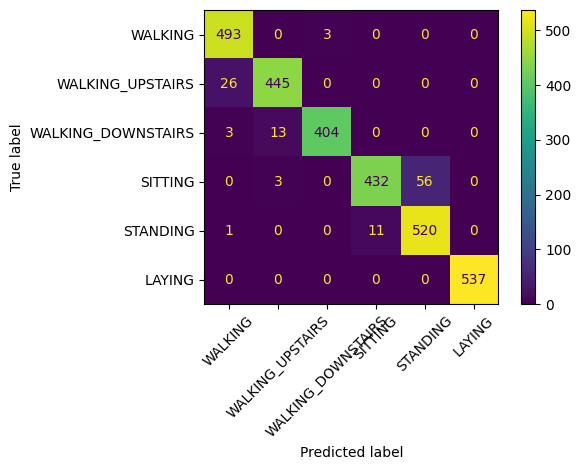

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

clf = LogisticRegression(max_iter=2000, n_jobs=-1)
clf.fit(X_train, y_train["label"])

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test["label"], y_pred)
f1  = f1_score(y_test["label"], y_pred, average="macro")

print(f"Accuracy: {acc:.4f}")
print(f"Macro F1 : {f1:.4f}")

cm = confusion_matrix(y_test["label"], y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=activity_labels["activity"])
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()